<a href="https://colab.research.google.com/github/OmkarRahate2004/Thiranex_Internship/blob/main/Thiranex_p4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# Make plots look professional
plt.style.use('ggplot')

# For reproducibility
np.random.seed(42)

In [7]:
# Load built-in dataset
cancer = load_breast_cancer()

# Convert to DataFrame
df = pd.DataFrame(
    data=cancer.data,
    columns=cancer.feature_names
)

# Add target column
df['target'] = cancer.target

# Convert target values to labels
df['diagnosis'] = df['target'].map({
    0: 'Malignant',
    1: 'Benign'
})

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


In [8]:
print("Shape of Dataset:", df.shape)

print("\nColumn Information:")
print(df.info())

print("\nStatistical Summary:")
display(df.describe())

Shape of Dataset: (569, 32)

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 no

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [9]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
diagnosis                  0
dtype: int64


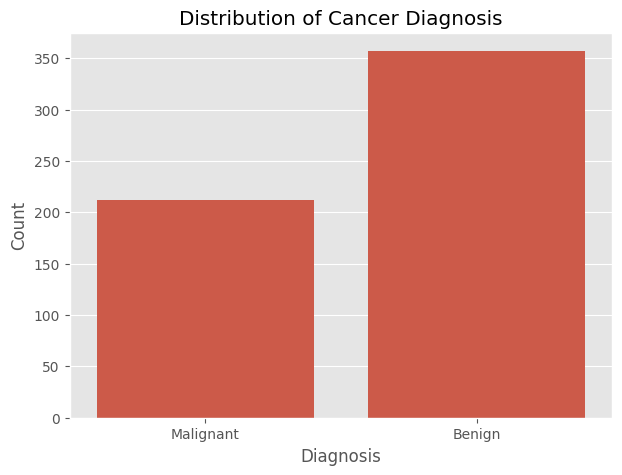

In [10]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='diagnosis',
    data=df
)

plt.title('Distribution of Cancer Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Count')

plt.savefig('class_distribution.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

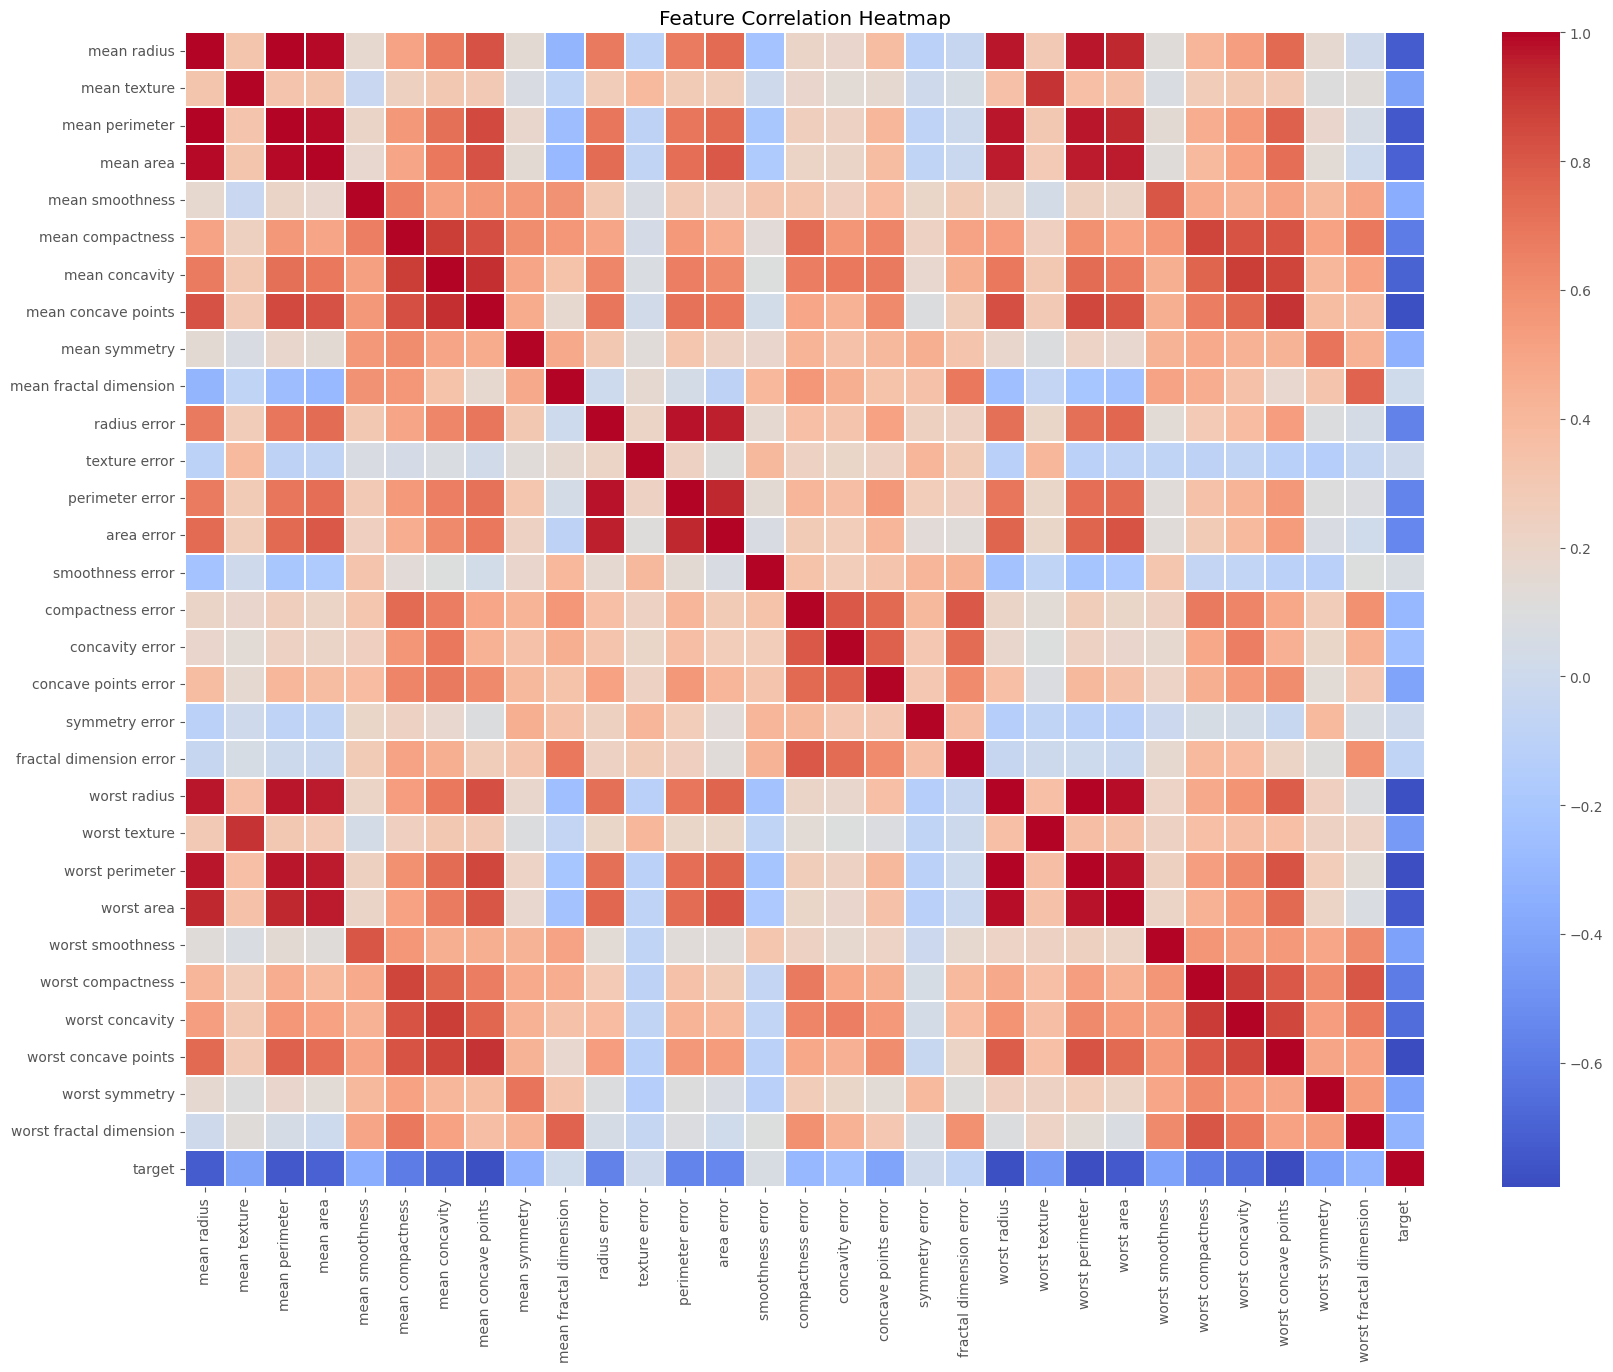

In [11]:
plt.figure(figsize=(20,15))

corr = df.drop(['diagnosis'], axis=1).corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    linewidths=0.1
)

plt.title('Feature Correlation Heatmap')
plt.savefig('correlation_heatmap.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

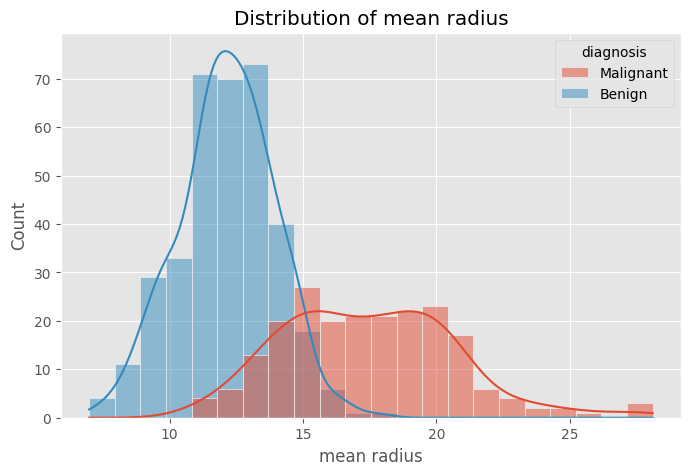

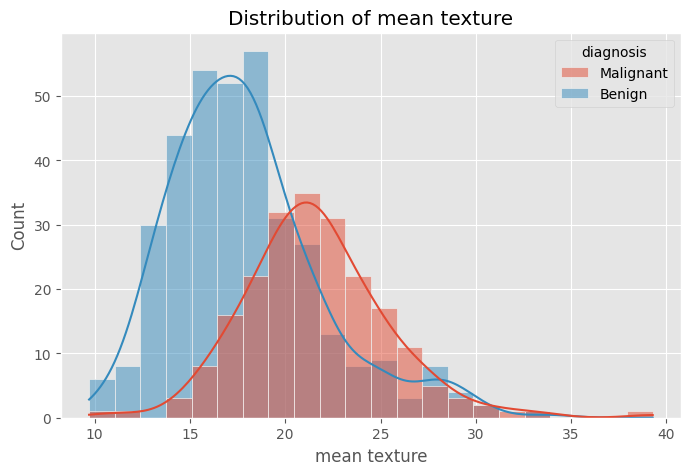

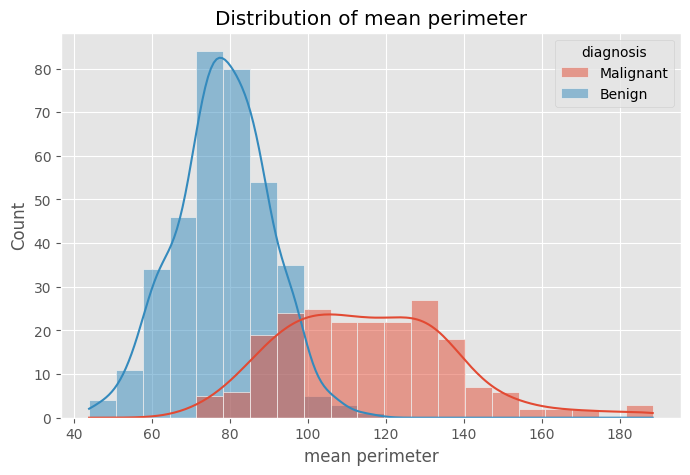

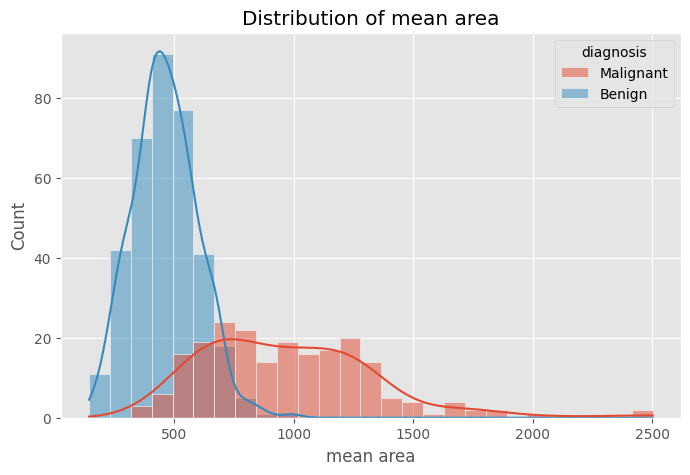

In [12]:
features = [
    'mean radius',
    'mean texture',
    'mean perimeter',
    'mean area'
]

for feature in features:

    plt.figure(figsize=(8,5))

    sns.histplot(
        data=df,
        x=feature,
        hue='diagnosis',
        kde=True
    )

    plt.title(f'Distribution of {feature}')

    plt.savefig(
        f'{feature.replace(" ","_")}.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

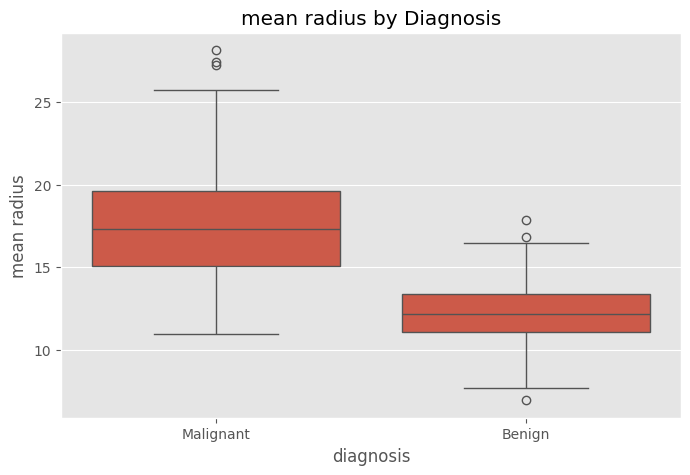

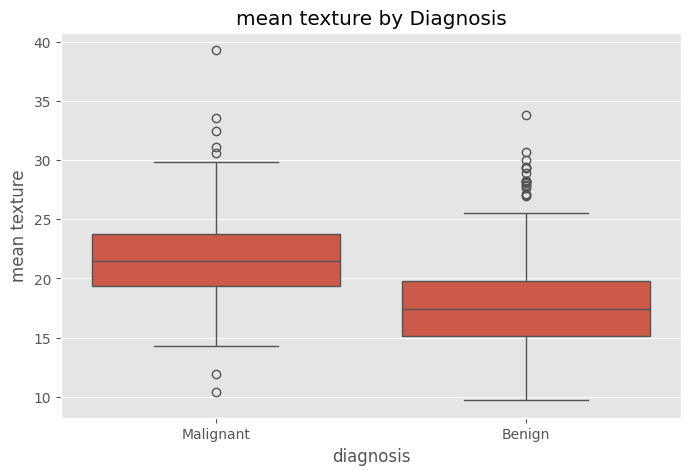

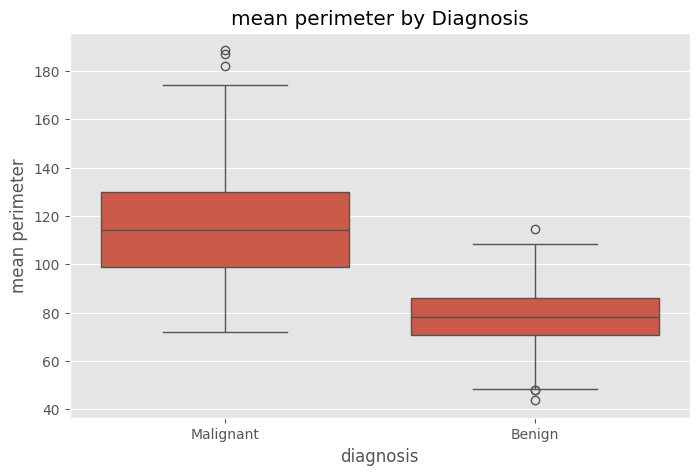

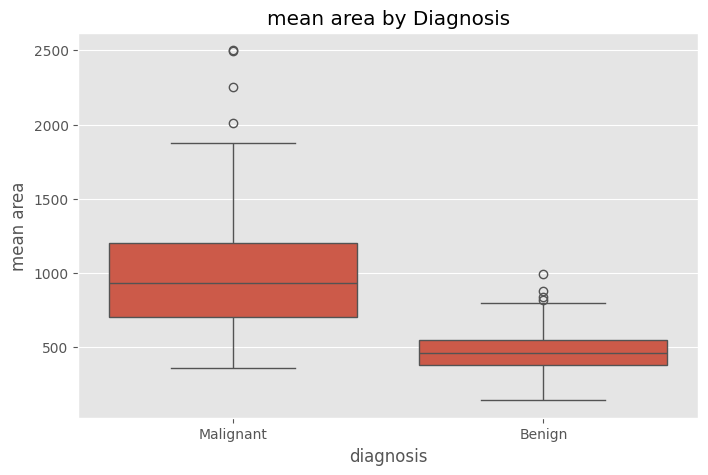

In [13]:
for feature in features:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        x='diagnosis',
        y=feature,
        data=df
    )

    plt.title(f'{feature} by Diagnosis')

    plt.savefig(
        f'box_{feature.replace(" ","_")}.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

In [14]:
X = df.drop(
    ['target', 'diagnosis'],
    axis=1
)

y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(
    X_train_scaled,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [17]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

In [18]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 95.61%


In [19]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



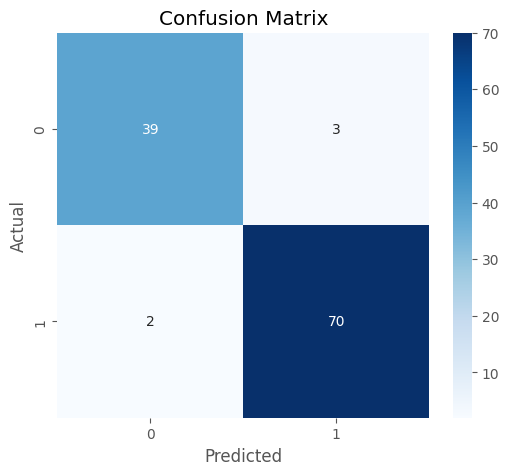

In [20]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.savefig(
    'confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

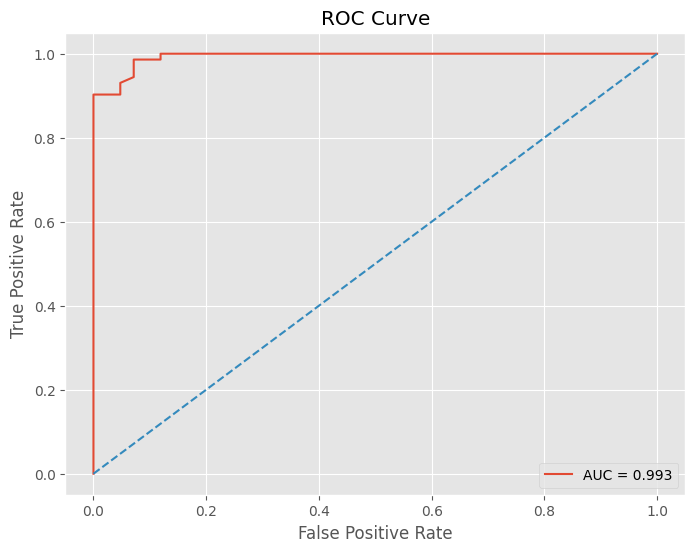

In [21]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {auc:.3f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.savefig(
    'roc_curve.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

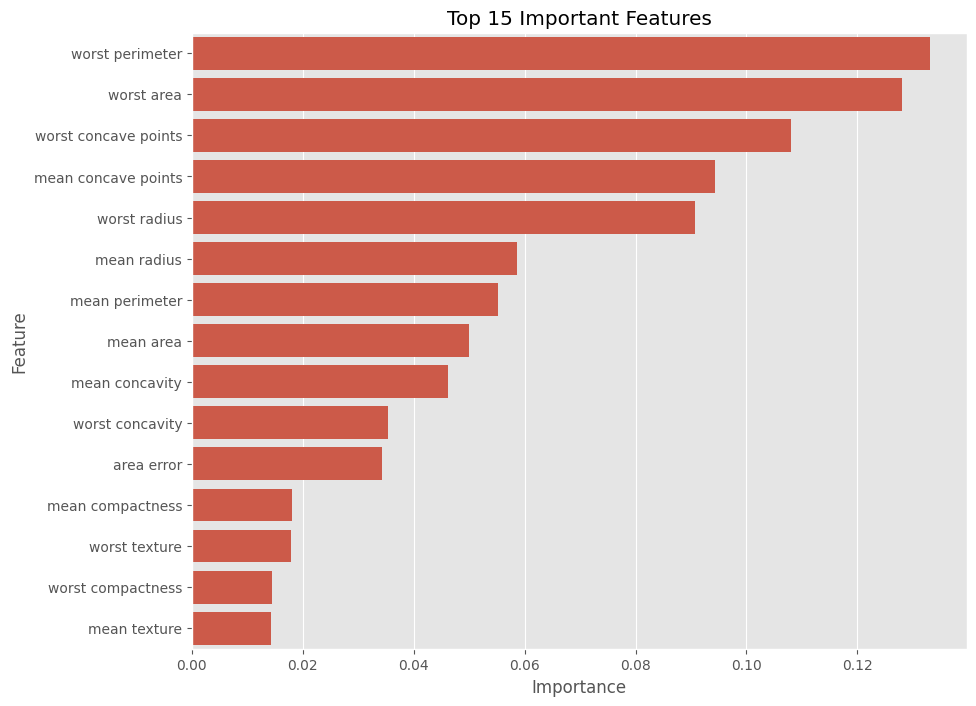

In [22]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Important Features')

plt.savefig(
    'feature_importance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [23]:
print("PROJECT CONCLUSION")
print("-"*50)
print(f"Model Accuracy : {accuracy:.2%}")
print(f"ROC-AUC Score  : {auc:.3f}")

print("\nKey Findings:")
print("1. Certain tumor characteristics strongly influence diagnosis.")
print("2. Features are highly correlated.")
print("3. Random Forest achieved excellent predictive performance.")
print("4. The model can assist in early cancer detection.")

PROJECT CONCLUSION
--------------------------------------------------
Model Accuracy : 95.61%
ROC-AUC Score  : 0.993

Key Findings:
1. Certain tumor characteristics strongly influence diagnosis.
2. Features are highly correlated.
3. Random Forest achieved excellent predictive performance.
4. The model can assist in early cancer detection.


In [24]:
import os

print("Saved Graph Files:")
for file in os.listdir():
    if file.endswith(".png"):
        print(file)

Saved Graph Files:
confusion_matrix.png
box_mean_texture.png
box_mean_area.png
box_mean_radius.png
mean_radius.png
correlation_heatmap.png
roc_curve.png
box_mean_perimeter.png
mean_texture.png
feature_importance.png
mean_perimeter.png
mean_area.png
class_distribution.png
